In [3]:
import os
import shap
import numpy as np
import pandas as pd
import seaborn as sns

import yfinance as yf
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import plot_tree

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler

# ================== DOWNLOAD ONCE ==================
def download_historical_data(tickers, start, end):
    threshold = 0.6  # drop if ≥80% NaN
    print(f"Downloading data from {start} to {end} ...")

    if end==datetime.now().strftime('%Y-%m-%d'):
        data = yf.download(tickers, start=start, progress=False, auto_adjust=True)
    else:
        end_date_plus_one = (datetime.strptime(end, '%Y-%m-%d') + timedelta(days=1)).strftime('%Y-%m-%d')
        data = yf.download(tickers, start=start, end=end_date_plus_one, progress=False, auto_adjust=True)

    last_row = data.iloc[-1]
    nan_ratio = last_row.isna().mean()

    if nan_ratio >= threshold:
        data = data.iloc[:-1]
        
    if isinstance(data.columns, pd.MultiIndex):
        data = data['Close'].copy()
        
    data.columns = [str(col) for col in data.columns]

    print(f"Download completed. Shape: {data.shape}")
    return data

# ================== Create Lag Data ==================
def lagcreation_tickets(df_m, tickers, lag, tickers_out):
    
    new_cols = {}
    
    for t in tickers:
        if t not in df_m.columns:
            continue
            
        lag_c=f"{t}_lag{lag}"
        new_cols[lag_c] = df_m[t].shift(lag)
        tickers_out.append(lag_c)

    df_lags = pd.DataFrame(new_cols, index=df_m.index)
    df_m = pd.concat([df_m, df_lags], axis=1)  

    return df_m    


In [5]:
# ================== Initial Data Process==================
data_start_date = '2006-07-20'
data_end_date   = datetime.now().strftime('%Y-%m-%d')        # Change this range as needed
lag=10

tickers = ['DX-Y.NYB', '^VIX', '^IXIC', '^GSPC', '^DJI', 'GC=F', 'SI=F', 'CL=F', 
           '^IRX', '^FVX', '^TNX', '^TYX', 'HYG', 'XLF', 'KRE', 'SPY', 'RSP']

print("Starting historical analysis...")
df = download_historical_data(tickers, data_start_date, data_end_date)

if df.empty:
    print("No data downloaded.")
    exit()

nan_locations = {}
for col in df.columns:
    nan_dates = df.index[df[col].isna()]
    if len(nan_dates) > 0:
        nan_locations[col] = nan_dates
#for col, dates in nan_locations.items():
#    print(f"\n{col}: {len(dates)} NaNs")
#    print(dates[-10:])  # show first 10 dates

cols=list(nan_locations.keys())
rolling_mean = df[cols].rolling(window=10, min_periods=1).mean().shift(-5)
df[cols] = df[cols].fillna(rolling_mean)

rolling_mean = df['HYG'].rolling(window=10, min_periods=1).mean().shift(-90)
df['HYG'] = df['HYG'].fillna(rolling_mean)

rolling_mean = df['HYG'].rolling(window=10, min_periods=1).mean().shift(-90)
df['HYG'] = df['HYG'].fillna(rolling_mean)

nan_locations = {}
for col in df.columns:
    nan_dates = df.index[df[col].isna()]
    if len(nan_dates) > 0:
        nan_locations[col] = nan_dates
for col, dates in nan_locations.items():
    print(f"\n{col}: {len(dates)} NaNs")
#    print(dates[-10:])  # show first 10 dates

tickers_ind = []
df_m = df.copy()
for t in tickers:
    if t not in df_m.columns:
        continue
    
    # Moving Averages
    MA9=f"{t}_MA9"
    MA20=f"{t}_MA20"
    MA60=f"{t}_MA60"
    Trend_Sign=f"{t}_TrendSign"
    Trend_Ratio=f"{t}_TrendRatio"
    ma9  = df_m[t].rolling(window=10, min_periods=1).mean()
    ma20 = df_m[t].rolling(window=21, min_periods=3).mean()
    ma60 = df_m[t].rolling(window=61, min_periods=10).mean()
    trend_sign = np.sign(ma20 - ma60) 
    trend_ratio=ma9/ma20
    
    df_m = pd.concat(
        [df_m,     
         pd.DataFrame({MA9: ma9, MA20: ma20, MA60: ma60, Trend_Sign: trend_sign, Trend_Ratio: trend_ratio})
        ],    
        axis=1
    )
         
    MACD=f"{t}_MACD"
    ema12 = df_m[t].ewm(span=12, adjust=False).mean()
    ema26 = df_m[t].ewm(span=26, adjust=False).mean()
    df_m[MACD] = ema12 - ema26
        
    RSI=f"{t}_RSI"
    delta = df_m[t].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = -delta.where(delta < 0, 0).rolling(14).mean()
    df_m[RSI] = 100 * gain / (gain + loss)
    if t=='^IRX':
        df_m[RSI] = df_m[RSI].fillna(50)

    tickers_ind.extend([MA9, Trend_Sign, MACD, RSI])
    
df_m['IXIC_GSPC_MA9log'] = np.log(df_m['^IXIC_MA9']) - np.log(df_m['^GSPC_MA9'])
df_m['DJI_GSPC_MA9log'] = np.log(df_m['^DJI_MA9']) - np.log(df_m['^GSPC_MA9'])

drop_list = {'^IXIC_MA9', '^IXIC_MA60', '^IXIC_TrendSign', '^IXIC_TrendRatio', '^IXIC_MACD', '^IXIC_RSI', 
             '^DJI_MA9', '^DJI_MA60', '^DJI_TrendSign', '^DJI_TrendRatio', '^DJI_MACD', '^DJI_RSI',
             '^GSPC_MA9', '^GSPC_MA60', '^GSPC_TrendSign', '^GSPC_TrendRatio', '^GSPC_MACD', '^GSPC_RSI'}
tickers_ind = [t for t in tickers_ind if t not in drop_list]

df_m['Yield_SpL']=df_m['^TYX']-df_m['^TNX']
df_m['Yield_SpS']=df_m['^TNX']-df_m['^FVX']
df_m['Yield_SpS1']=df_m['^TNX']-df_m['^IRX']

df_m['Breadth_R']=df_m['RSP']/df_m['SPY']
df_m['Breadth_Signal']=df_m['Breadth_R'].rolling(21).mean()-df_m['Breadth_R'].rolling(61).mean()
df_m['Breadth_10D']=df_m['Breadth_R']/df_m['Breadth_R'].shift(11)-1
df_m['Breadth_21D']=df_m['Breadth_R']/df_m['Breadth_R'].shift(22)-1

tickers_ind.extend(['Yield_SpL', 'Yield_SpS', 'Yield_SpS1', 'Breadth_R', 'Breadth_Signal', 'Breadth_10D', 'Breadth_21D', 
                    'IXIC_GSPC_MA9log', 'DJI_GSPC_MA9log'])

df_m['TNX_Diff']=df_m['^TNX']-df_m['^TNX'].shift(9)
df_m['HYG_Diff']=np.log(df_m['HYG'])-np.log(df_m['HYG'].shift(9))
df_m['Credit_Stress']=((df_m['^TNX_TrendSign']==1) & (df_m['HYG_TrendSign']==-1)).astype(int)

tickers_dep = ['Credit_Stress']

tickers_ind_lag = f"tickers_ind_lag{lag}"
tickers_ind_lag = []
df_m=lagcreation_tickets(df_m, tickers_ind, lag, tickers_ind_lag)

Starting historical analysis...
Download completed. Shape: (4988, 17)


In [7]:
# ================== Modeling Data Processing==================
start_date = '2006-11-01'
tickers_model=tickers_dep+tickers_ind_lag

df_model = df_m.loc[df_m.index >= start_date, tickers_model].copy()
df_future = df_m.iloc[-lag:,:][tickers_ind].copy()

df_model.columns = df_model.columns.str.replace(f"_lag{lag}", '')

print(df_model.isna().sum()[df_model.isna().sum() > 0].sort_values(ascending=False))

corr = df_model[tickers_ind].corr()
#print(corr)

def get_high_corr_pairs(corr_matrix, threshold=0.9):
    corr_pairs = []
    cols = corr_matrix.columns

    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                corr_pairs.append((cols[i], cols[j], corr_matrix.iloc[i, j]))
                print (cols[i], cols[j], corr_matrix.iloc[i, j])

    return corr_pairs

high_corr = get_high_corr_pairs(corr, threshold=0.90)

Series([], dtype: int64)
^IRX_MA9 ^FVX_MA9 0.90305331752201
^FVX_MA9 ^TNX_MA9 0.937731751256951
^FVX_MACD ^TNX_MACD 0.9427252017240089
^FVX_RSI ^TNX_RSI 0.9442511871518273
^TNX_MA9 ^TYX_MA9 0.9477645036740246
^TNX_MACD ^TYX_MACD 0.94313041089312
^TNX_RSI ^TYX_RSI 0.9400781409399823
HYG_MA9 SPY_MA9 0.9245364949445313
HYG_MA9 RSP_MA9 0.9512587662210518
HYG_MA9 IXIC_GSPC_MA9log 0.9586766875881327
XLF_MA9 KRE_MA9 0.9074425452713056
XLF_MA9 SPY_MA9 0.9744190979166157
XLF_MA9 RSP_MA9 0.964050662197059
XLF_MA9 DJI_GSPC_MA9log -0.9124396908081195
KRE_MA9 RSP_MA9 0.9098461416188021
SPY_MA9 RSP_MA9 0.9901923576169168
SPY_MA9 DJI_GSPC_MA9log -0.9277020295747503
SPY_MACD RSP_MACD 0.9014489689203806
SPY_RSI RSP_RSI 0.9343684879658778
RSP_MA9 IXIC_GSPC_MA9log 0.9147236078128252
RSP_MA9 DJI_GSPC_MA9log -0.9093959588796432
Yield_SpL Yield_SpS 0.9105792047327999


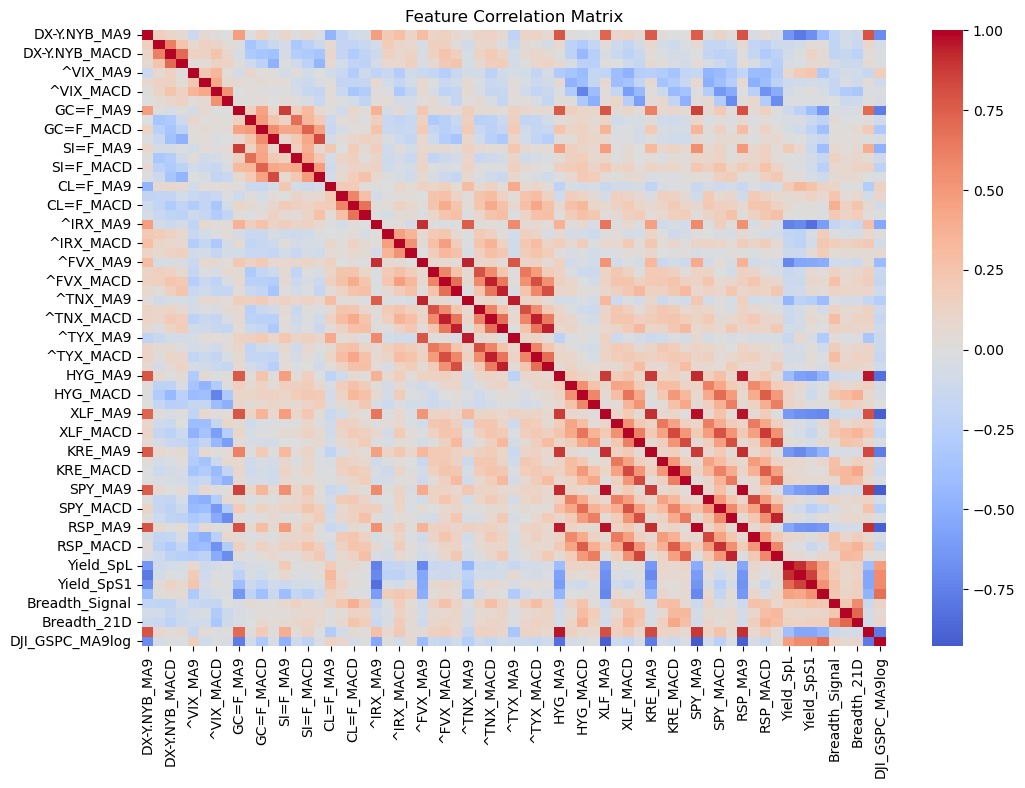

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [11]:
# ================== Modeling Data Set Processing==================
split_date = '2024-10-01'
split_date1 = '2025-09-01'

df_train=df_model.loc[df_model.index<=split_date,:].copy()
df_val=df_model.loc[(df_model.index>split_date) & (df_model.index<=split_date1),:].copy()
df_test=df_model.loc[df_model.index>split_date1, :].copy()

print(df_train.shape, df_val.shape, df_test.shape)
print(df_train['Credit_Stress'].value_counts(normalize=True))
print(df_val['Credit_Stress'].value_counts(normalize=True))
print(df_test['Credit_Stress'].value_counts(normalize=True))

#print(df_train[tickers_ind].min())
#print(df_train[tickers_ind].quantile([0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
#print(df_train[tickers_ind].max())

#print(df_val[tickers_ind].min())
#print(df_val[tickers_ind].quantile([0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
#print(df_val[tickers_ind].max())

#print(df_test[tickers_ind].min())
#print(df_test[tickers_ind].quantile([0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
#print(df_test[tickers_ind].max())

(4511, 66) (231, 66) (172, 66)
Credit_Stress
0    0.843715
1    0.156285
Name: proportion, dtype: float64
Credit_Stress
0    0.961039
1    0.038961
Name: proportion, dtype: float64
Credit_Stress
0    0.889535
1    0.110465
Name: proportion, dtype: float64


In [13]:
# ================== GXBoost Modelling ==================
model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,    
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    early_stopping_rounds=20)

model_xgb.fit(df_train[tickers_ind], df_train['Credit_Stress'],
             eval_set=[(df_val[tickers_ind], df_val['Credit_Stress'])], 
             verbose=True)      

[0]	validation_0-auc:0.80506
[1]	validation_0-auc:0.80806
[2]	validation_0-auc:0.80706
[3]	validation_0-auc:0.81056
[4]	validation_0-auc:0.81056
[5]	validation_0-auc:0.81106
[6]	validation_0-auc:0.87513
[7]	validation_0-auc:0.87012
[8]	validation_0-auc:0.87462
[9]	validation_0-auc:0.88088
[10]	validation_0-auc:0.89039
[11]	validation_0-auc:0.89139
[12]	validation_0-auc:0.89139
[13]	validation_0-auc:0.89139
[14]	validation_0-auc:0.89039
[15]	validation_0-auc:0.89239
[16]	validation_0-auc:0.89089
[17]	validation_0-auc:0.88939
[18]	validation_0-auc:0.88488
[19]	validation_0-auc:0.88589
[20]	validation_0-auc:0.88739
[21]	validation_0-auc:0.88939
[22]	validation_0-auc:0.88589
[23]	validation_0-auc:0.88589
[24]	validation_0-auc:0.88338
[25]	validation_0-auc:0.88539
[26]	validation_0-auc:0.88438
[27]	validation_0-auc:0.88488
[28]	validation_0-auc:0.88589
[29]	validation_0-auc:0.88238
[30]	validation_0-auc:0.88839
[31]	validation_0-auc:0.88989
[32]	validation_0-auc:0.89039
[33]	validation_0-au

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,'auc'


In [15]:
# ================== GXBoost Model Performance ==================
y_prob = model_xgb.predict_proba(df_test[tickers_ind])[:, 1]

dtest = xgb.DMatrix(df_test[tickers_ind])
raw_score = model_xgb.predict(df_test[tickers_ind], output_margin=True)
prob = 1 / (1 + np.exp(-raw_score))
pred = (prob > 0.156285).astype(int)  

prob_diff=y_prob-prob
print(prob_diff.sum())

print(confusion_matrix(df_test['Credit_Stress'], pred))
print(classification_report(df_test['Credit_Stress'], pred))
print(roc_auc_score(df_test['Credit_Stress'], prob))

dtest = xgb.DMatrix(df_future[tickers_ind])
raw_score_f = model_xgb.predict(df_future[tickers_ind], output_margin=True)
prob_f = 1 / (1 + np.exp(-raw_score_f))
pred_f = (prob_f > 0.156285).astype(int)
print(prob_f, pred_f)

-1.5133992e-08
[[145   8]
 [  1  18]]
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       153
           1       0.69      0.95      0.80        19

    accuracy                           0.95       172
   macro avg       0.84      0.95      0.88       172
weighted avg       0.96      0.95      0.95       172

0.9886480908152736
[0.01868957 0.01743028 0.01729083 0.03819473 0.02959387 0.02881582
 0.03831776 0.04111214 0.02405808 0.02446915] [0 0 0 0 0 0 0 0 0 0]


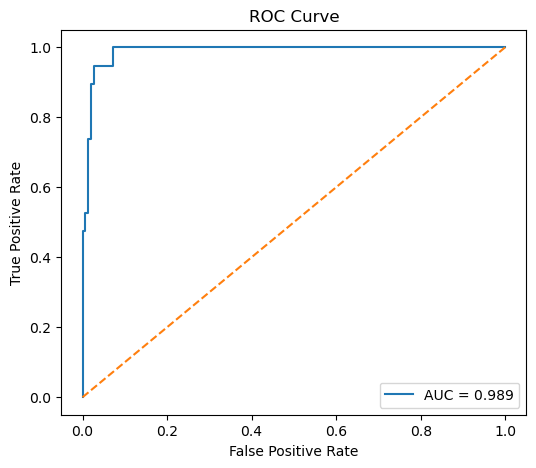

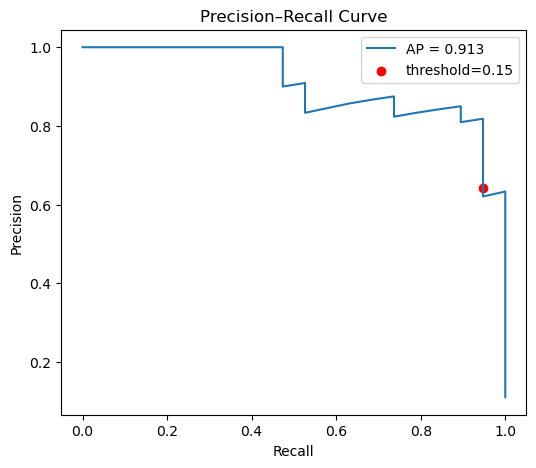

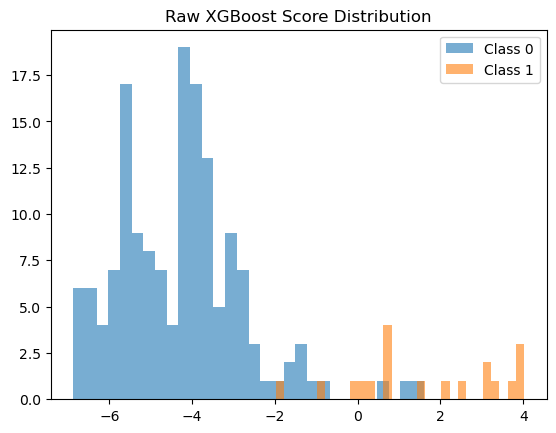

In [17]:
fpr, tpr, thresholds = roc_curve(df_test['Credit_Stress'], y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

precision, recall, thresholds = precision_recall_curve(df_test['Credit_Stress'], y_prob)
ap = average_precision_score(df_test['Credit_Stress'], y_prob)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
# find closest threshold index
idx = (np.abs(thresholds - 0.15)).argmin()
plt.scatter(recall[idx], precision[idx], color='red', label="threshold=0.15")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

plt.hist(raw_score[df_test['Credit_Stress']==0], bins=30, alpha=0.6, label="Class 0")
plt.hist(raw_score[df_test['Credit_Stress']==1], bins=30, alpha=0.6, label="Class 1")
plt.legend()
plt.title("Raw XGBoost Score Distribution")
plt.show()

142
0:[HYG_MACD<-0.0307508186] yes=1,no=2,missing=2
	1:[^TNX_MACD<-0.00196092669] yes=3,no=4,missing=4
		3:[^TYX_TrendSign<1] yes=7,no=8,missing=8
			7:[Breadth_21D<-0.0655488521] yes=15,no=16,missing=16
				15:leaf=0.00942711439
				16:leaf=-0.0581021197
			8:[KRE_MA9<18.0064011] yes=17,no=18,missing=18
				17:leaf=0.205810353
				18:leaf=-0.02428657
		4:[^FVX_TrendSign<1] yes=9,no=10,missing=10
			9:[^IRX_MA9<1.61680007] yes=19,no=20,missing=20
				19:leaf=0.154941782
				20:leaf=-0.032170888
			10:[Yield_SpS<1.30400014] yes=21,no=22,missing=22
				21:leaf=0.293299854
				22:leaf=0.0525566339
	2:[HYG_MACD<0.0128554925] yes=5,no=6,missing=6
		5:[^FVX_MACD<0.0247848593] yes=11,no=12,missing=12
			11:[^TYX_MACD<0.0158603694] yes=23,no=24,missing=24
				23:leaf=-0.0549643748
				24:leaf=0.0200175904
			12:[DX-Y.NYB_MA9<82.3339996] yes=25,no=26,missing=26
				25:leaf=-0.033702407
				26:leaf=0.163542092
		6:[KRE_MA9<62.5597458] yes=13,no=14,missing=14
			13:[^TYX_MACD<0.0304291751] yes=27

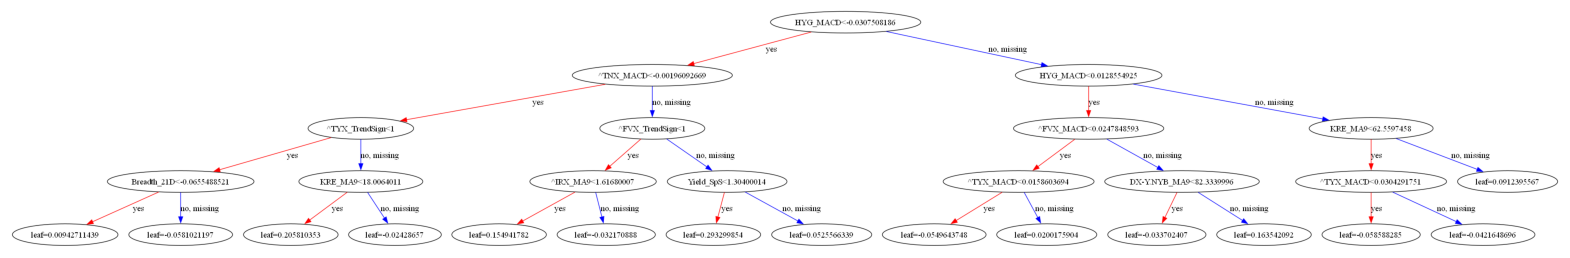

In [19]:
# ================== GXBoost Model Tree Check ==================
booster = model_xgb.get_booster()
trees = booster.get_dump()
print(len(trees))
print(trees[0])
print(trees[5])

fig, ax = plt.subplots(figsize=(20,10))
plot_tree(model_xgb, tree_idx=0, ax=ax)
plt.show()

In [21]:
# ================== GXBoost Model Feature Importance Check ==================
model_xgb.feature_importances_
booster.get_score(importance_type='gain')

explainer = shap.Explainer(model_xgb.predict, df_test[tickers_ind])
shap_values = explainer(df_test[tickers_ind])

importance = np.abs(shap_values.values).mean(axis=0)

feature_importance = pd.Series(importance, index=df_test[tickers_ind].columns)

pd.set_option('display.max_rows', None)
print(feature_importance.sort_values(ascending=False))

PermutationExplainer explainer: 173it [00:11,  3.14it/s]                                                               

HYG_MACD              0.098130
^TNX_MACD             0.028547
CL=F_MACD             0.016308
^FVX_TrendSign        0.014234
^TYX_TrendSign        0.012413
^TNX_TrendSign        0.012190
^FVX_MACD             0.011948
HYG_TrendSign         0.011831
SI=F_MACD             0.007888
^TYX_MACD             0.005843
Breadth_10D           0.004952
SPY_MACD              0.004680
KRE_MA9               0.004448
HYG_RSI               0.004041
CL=F_MA9              0.003362
KRE_MACD              0.002907
^VIX_MA9              0.002267
^VIX_RSI              0.002258
Breadth_Signal        0.002093
XLF_MACD              0.001880
DX-Y.NYB_MACD         0.001860
GC=F_MACD             0.001686
Yield_SpL             0.001395
^IRX_MACD             0.001376
KRE_RSI               0.001337
^FVX_RSI              0.001298
DX-Y.NYB_TrendSign    0.001211
GC=F_RSI              0.001066
DX-Y.NYB_RSI          0.000969
^VIX_MACD             0.000950
Breadth_21D           0.000891
RSP_MACD              0.000717
Yield_Sp

In [23]:
# ================== GXBoost Reduced Model with Top Features ==================
top_features = feature_importance.sort_values(ascending=False).head(30).index.tolist()
model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,    
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    early_stopping_rounds=20)

model_xgb.fit(df_train[top_features], df_train['Credit_Stress'],
             eval_set=[(df_val[top_features], df_val['Credit_Stress'])], 
             verbose=True)     

[0]	validation_0-auc:0.80280
[1]	validation_0-auc:0.77352
[2]	validation_0-auc:0.79555
[3]	validation_0-auc:0.81757
[4]	validation_0-auc:0.81406
[5]	validation_0-auc:0.81456
[6]	validation_0-auc:0.81381
[7]	validation_0-auc:0.79505
[8]	validation_0-auc:0.81306
[9]	validation_0-auc:0.81206
[10]	validation_0-auc:0.81206
[11]	validation_0-auc:0.81106
[12]	validation_0-auc:0.81632
[13]	validation_0-auc:0.81782
[14]	validation_0-auc:0.81782
[15]	validation_0-auc:0.81932
[16]	validation_0-auc:0.83509
[17]	validation_0-auc:0.83358
[18]	validation_0-auc:0.85260
[19]	validation_0-auc:0.85310
[20]	validation_0-auc:0.84309
[21]	validation_0-auc:0.84960
[22]	validation_0-auc:0.84810
[23]	validation_0-auc:0.84710
[24]	validation_0-auc:0.84560
[25]	validation_0-auc:0.84610
[26]	validation_0-auc:0.83809
[27]	validation_0-auc:0.83108
[28]	validation_0-auc:0.83609
[29]	validation_0-auc:0.83408
[30]	validation_0-auc:0.82808
[31]	validation_0-auc:0.84660
[32]	validation_0-auc:0.84760
[33]	validation_0-au

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,'auc'


In [27]:
# ================== GXBoost Reduced Model Performance ==================
dtest = xgb.DMatrix(df_test[top_features])
raw_score = model_xgb.predict(df_test[top_features], output_margin=True)
prob = 1 / (1 + np.exp(-raw_score))
pred = (prob > 0.156285).astype(int)  

print(confusion_matrix(df_test['Credit_Stress'], pred))
print(classification_report(df_test['Credit_Stress'], pred))
print(roc_auc_score(df_test['Credit_Stress'], prob))

[[143  10]
 [  1  18]]
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       153
           1       0.64      0.95      0.77        19

    accuracy                           0.94       172
   macro avg       0.82      0.94      0.86       172
weighted avg       0.95      0.94      0.94       172

0.978672170622635


In [33]:
# ================== Neural Network Modelling ==================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(df_train[tickers_ind])
X_val_scaled = scaler.transform(df_val[tickers_ind])
X_test_scaled = scaler.transform(df_test[tickers_ind])
X_future_scaled = scaler.transform(df_future[tickers_ind])

print (X_train_scaled.shape)
print (df_train['Credit_Stress'].shape)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(65,)),
    
    Dense(60),
    LeakyReLU(negative_slope=0.2),

    Dense(30),
    LeakyReLU(negative_slope=0.1),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), #'adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

class_weight={0:1, 1:6}
model.fit(
    X_train_scaled,
    df_train['Credit_Stress'],
    validation_data=(X_val_scaled, df_val['Credit_Stress']),
    epochs=20,
    batch_size=32,
    class_weight=class_weight,
    verbose=1
)

(4511, 65)
(4511,)
Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7220 - loss: 0.7418 - val_accuracy: 0.8355 - val_loss: 0.3871
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9051 - loss: 0.3725 - val_accuracy: 0.8398 - val_loss: 0.3311
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9231 - loss: 0.2829 - val_accuracy: 0.8745 - val_loss: 0.2950
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 885us/step - accuracy: 0.9377 - loss: 0.2329 - val_accuracy: 0.8918 - val_loss: 0.2545
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9472 - loss: 0.2007 - val_accuracy: 0.8745 - val_loss: 0.2924
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9532 - loss: 0.1716 - val_accuracy: 0.8312 - val_loss: 0.4027
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9572 - loss: 0.1518 - val_accuracy: 0.8571 - val_loss: 0.3556
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9643 - loss: 0.13

In [35]:
# ================== Neural Network Model Performance Check ==================
y_prob = model.predict(X_test_scaled)
y_pred = (y_prob > 0.156285).astype(int)

print(confusion_matrix(df_test['Credit_Stress'], y_pred))
print(classification_report(df_test['Credit_Stress'], y_pred))
print(roc_auc_score(df_test['Credit_Stress'], y_prob))

prob_f = model.predict(X_future_scaled)
pred_f = (prob_f > 0.156285).astype(int)
print(prob_f, pred_f)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
[[153   0]
 [ 13   6]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       153
           1       1.00      0.32      0.48        19

    accuracy                           0.92       172
   macro avg       0.96      0.66      0.72       172
weighted avg       0.93      0.92      0.91       172

0.9979360165118679
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[[2.2732977e-12]
 [5.1163349e-12]
 [1.4082836e-10]
 [2.5763958e-09]
 [2.0398272e-09]
 [2.4026376e-09]
 [4.2958401e-08]
 [1.5775467e-07]
 [3.6952020e-08]
 [1.1073427e-07]] [[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]


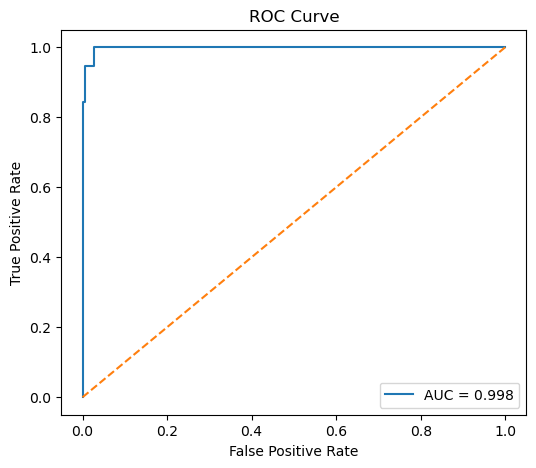

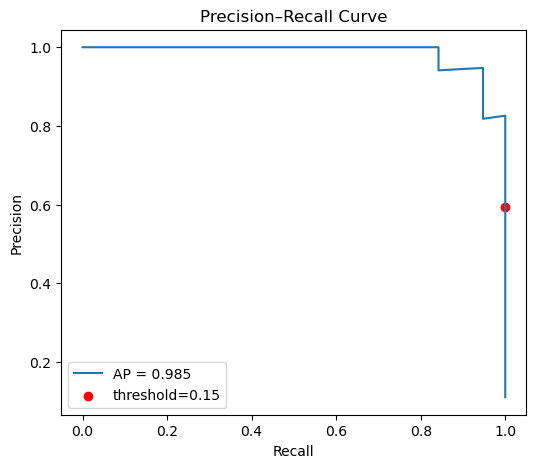

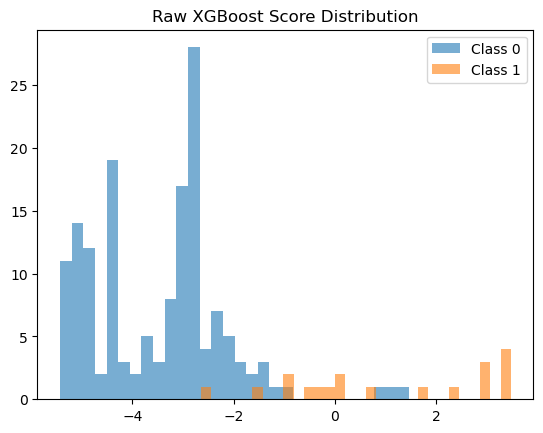

In [37]:
fpr, tpr, thresholds = roc_curve(df_test['Credit_Stress'], y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

precision, recall, thresholds = precision_recall_curve(df_test['Credit_Stress'], y_prob)
ap = average_precision_score(df_test['Credit_Stress'], y_prob)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.scatter(recall[idx], precision[idx], color='red', label="threshold=0.15")
# find closest threshold index
idx = (np.abs(thresholds - 0.15)).argmin()
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

plt.hist(raw_score[df_test['Credit_Stress']==0], bins=30, alpha=0.6, label="Class 0")
plt.hist(raw_score[df_test['Credit_Stress']==1], bins=30, alpha=0.6, label="Class 1")
plt.legend()
plt.title("Raw XGBoost Score Distribution")
plt.show()

In [39]:
# ================== Neural Network Model Check ==================
weights, biases = model.layers[0].get_weights()
print(weights.shape)

for layer in model.layers:
    print(layer.get_weights())

(65, 60)
[array([[ 0.22092564, -0.28296173,  0.10918424, ...,  0.04827783,
         0.11867426,  0.0428653 ],
       [ 0.1969466 , -0.04462649,  0.10763203, ..., -0.00568057,
         0.21559067, -0.09692829],
       [ 0.17423715, -0.02260634,  0.08625878, ...,  0.13332728,
         0.19527793, -0.14474632],
       ...,
       [ 0.15010552,  0.15002397, -0.01860435, ...,  0.10820059,
         0.14687441,  0.16596486],
       [-0.24932393, -0.08365372,  0.04012795, ...,  0.09517545,
        -0.04065433, -0.03016342],
       [-0.02942394,  0.12082812, -0.05999973, ...,  0.18845329,
         0.07024855, -0.11834882]], dtype=float32), array([ 0.01073785,  0.0746691 ,  0.03760152, -0.03687073, -0.04385832,
       -0.00971517,  0.11703173,  0.04402465, -0.04865399,  0.09913084,
       -0.01473111,  0.11837978, -0.00162783, -0.01629355,  0.08248441,
        0.0127368 ,  0.12316917,  0.07136287,  0.10930239,  0.13507779,
       -0.01828104,  0.02125377, -0.05429231,  0.0186222 ,  0.07861941,
 